In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [9]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

digits = [0,1]
mnist = MNISTDataset(ROOT='../notebooks/datasets/',digits=digits)
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [10]:
set_seed(437438)
mlp_base = MLP(
    input_dim=784,
    hidden_dims=[32,32],
    output_dim=len(digits)
)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [39]:
LOADER_SEED = 645297
batch_size = 128
n_epoch = 10
K = 128
RTOL = 1e-4
LR = 1e-3
LR_SVD = 0.5

### Train MLP with Adam

In [13]:
model_adam = MLP(input_dim=784, hidden_dims=[32,32], output_dim=len(digits))
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR)
#loss_fn = nn.CrossEntropyLoss()
def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #pred = F.softmax(pred, dim=1)
    return (pred - y).pow(2).sum(dim=1).mean()

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cpu


100%|██████████| 10/10 [00:01<00:00,  9.38it/s]


### Train MLP with Sven

In [40]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_svd = MLP(input_dim=784, hidden_dims=[32,32], output_dim=len(digits))
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    #pred = F.softmax(pred, dim=1)
    return (pred - y).pow(2).sum(dim=1)


model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized', use_rmsprop=False)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

torch.compiler.reset()

100%|██████████| 10/10 [02:33<00:00, 15.32s/it]


### manually check variable-k

In [6]:
model_svd = MLP(input_dim=784, hidden_dims=[32,32,32], output_dim=10)
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    fn = torch.nn.CrossEntropyLoss(reduction='none')
    loss = fn(pred, y).squeeze()
    #y = y.squeeze() # shape (B,)
    #targ = -1*torch.ones_like(pred)
    #targ[torch.arange(y.shape[0]).to(y), y] = 1.0
    #loss = -((targ*pred)**2).sum(dim=1)
    return loss

model_svd = FunctionalModelJac(model_svd, loss_fn, device=device)
optimizer = SVDOptimizer(model_svd,lr=LR,k=K,rtol=RTOL,track_svd_info=True,svd_mode='randomized',variable_k=True, use_rmsprop=True)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

ib = 0
ministeps = []
for batch in train_loader:
    xb, yb = batch
    xb = xb.to(device)
    yb = yb.to(device)
    batch = (xb, yb)
    batch_losses, ypred = model_svd.loss_and_grad(batch)

    with torch.no_grad():
        jacobian = model_svd.grads
        losses = model_svd.losses
        VhT, S_inv, U_T = optimizer._get_pinv(jacobian)

        updates = []
        for k in range(len(S_inv)):
            updates.append(optimizer._compute_delta_k_compiled(k, U_T, S_inv, VhT, losses, 0.05))

        losses_miniStep = [losses.mean().item()]
        for u in updates:
            optimizer._apply_update(u)
            x, *args = batch
            new_loss = model_svd.evaluate_and_loss(x, *args).mean().item()
            losses_miniStep.append(new_loss)
        ministeps.append(losses_miniStep)
    ib += 1

    if ib == 100:
        break

KeyboardInterrupt: 

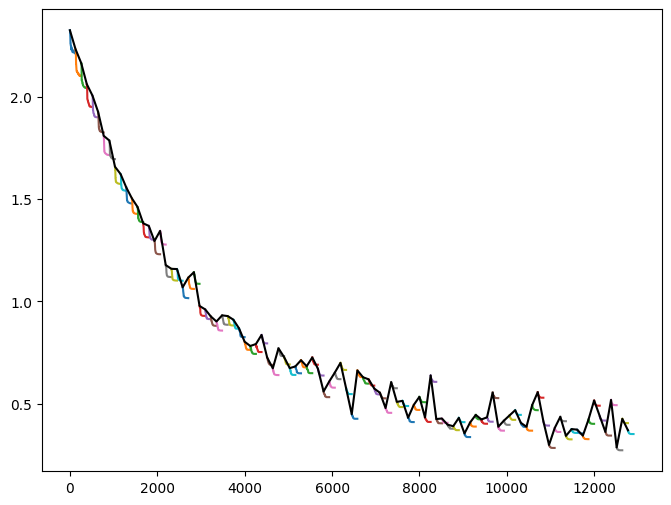

In [28]:
plt.figure(figsize=(8,6))
lo = 0
xtot = []
for ms in ministeps:
    xvals = np.arange(lo,lo+len(ms))
    xtot.append(lo)
    lo += len(ms)
    plt.plot(xvals, ms)
plt.plot(xtot,[ms[0] for ms in ministeps], color='k')

### compare adam vs sven

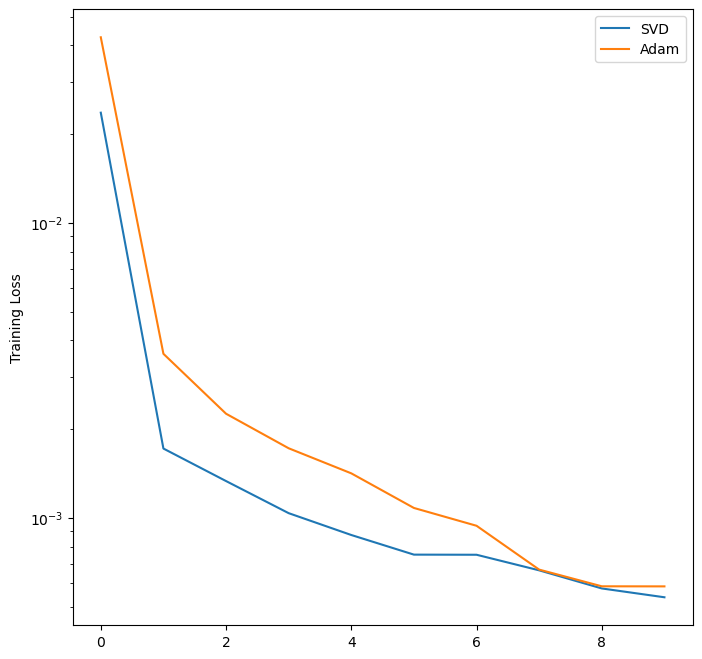

In [41]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train'],label='SVD')
plt.plot(losses_adam['train'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')

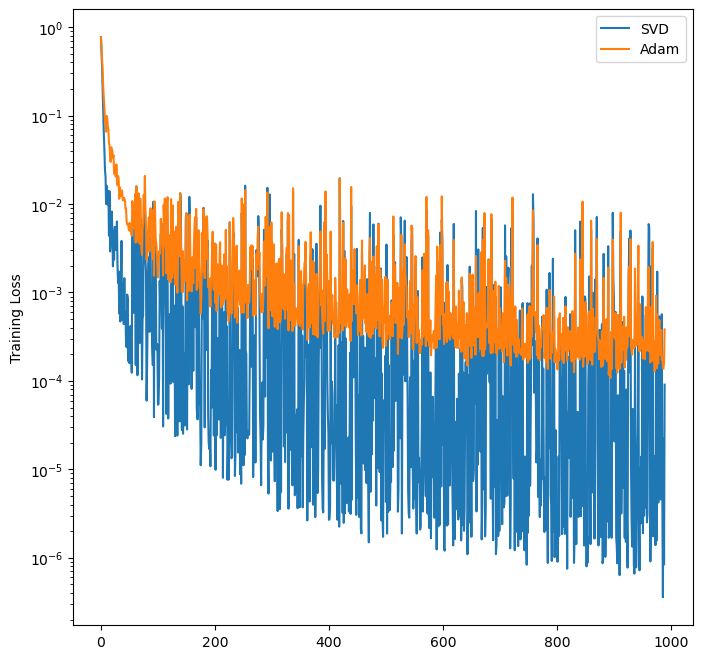

In [42]:
plt.figure(figsize=(8,8))
plt.plot(losses_svd['train_batch'],label='SVD')
plt.plot(losses_adam['train_batch'],label='Adam')
plt.legend()
plt.ylabel("Training Loss")
#plt.xlim(0,20)
plt.yscale('log')

(0.0, 500.0)

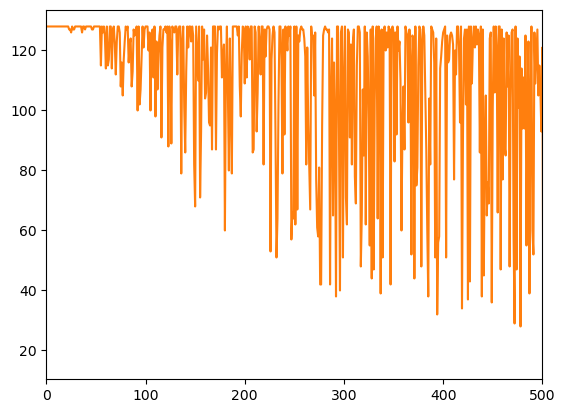

In [43]:
plt.plot(svd_info['k_used'])
plt.plot(svd_info['num_nonzero_svs'])
plt.xlim(0,500)

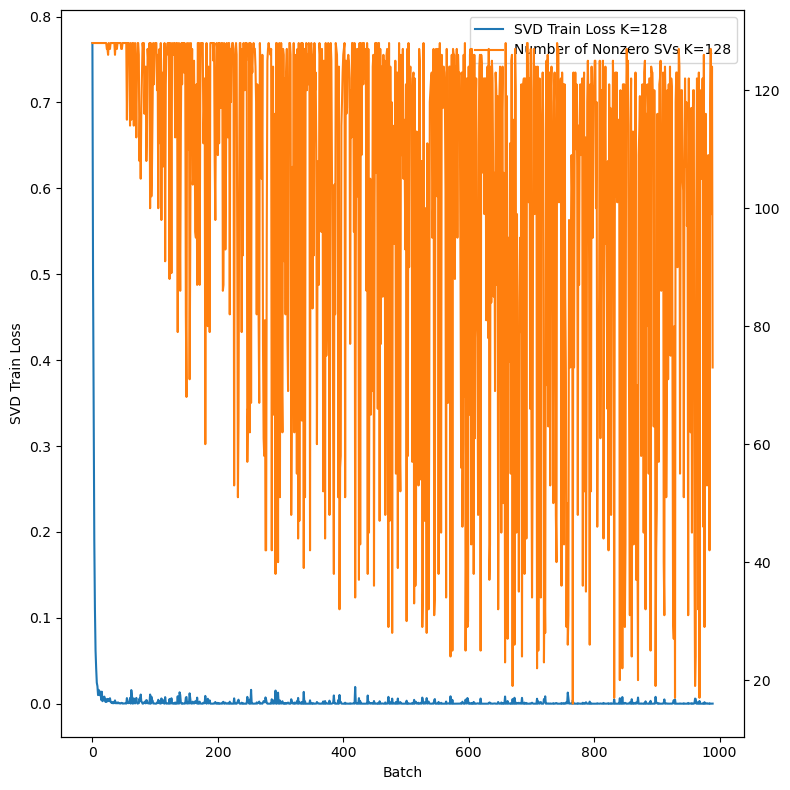

In [44]:
fig, ax1 = plt.subplots(figsize=(8,8))

plots = []
p1 = ax1.plot(np.arange(len(losses_svd['train_batch'])), losses_svd['train_batch'], 'C0', label=f'SVD Train Loss K={K}')
plots.append(p1[0])
ax1.set_xlabel('Batch')
ax1.set_ylabel('SVD Train Loss')
ax1.legend()

ax2 = ax1.twinx()
p2 = ax2.plot(np.arange(len(svd_info['num_nonzero_svs'])), svd_info['num_nonzero_svs'], 'C1-',label=f'Number of Nonzero SVs K={K}')

ax1.legend(handles=[p1[0],p2[0]])
plt.tight_layout()

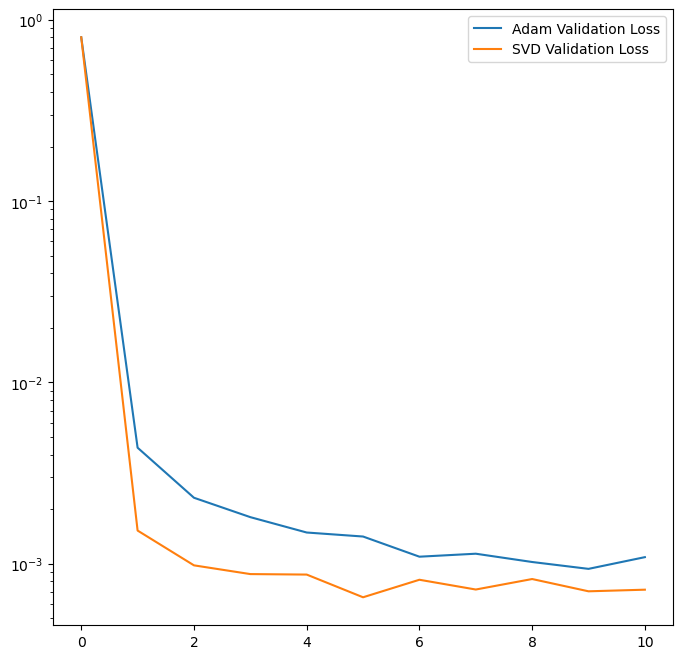

In [45]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['val'])), losses_adam['val'], label='Adam Validation Loss')
ax.plot(np.arange(len(losses_svd['val'])), losses_svd['val'], label='SVD Validation Loss')
plt.yscale('log')
plt.legend()

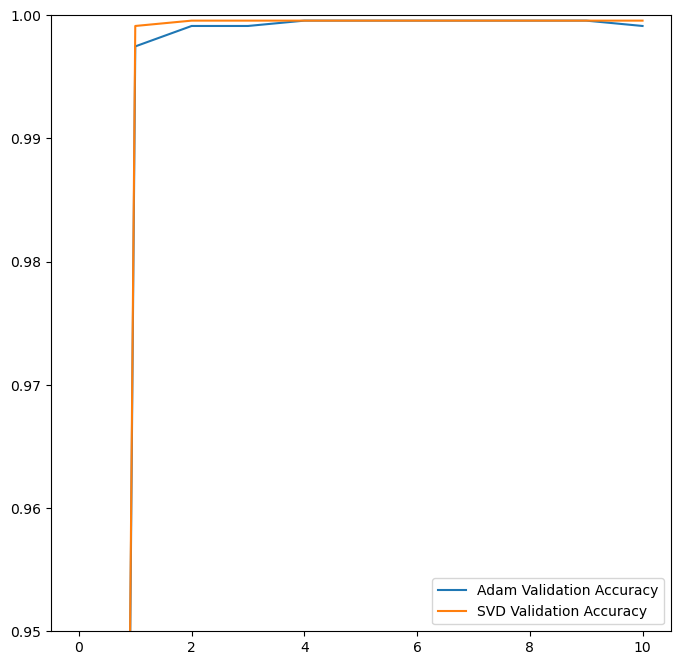

In [46]:
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(np.arange(len(losses_adam['val_acc'])), losses_adam['val_acc'], label='Adam Validation Accuracy')
ax.plot(np.arange(len(losses_svd['val_acc'])), losses_svd['val_acc'], label='SVD Validation Accuracy')
#plt.yscale('log')
plt.ylim([0.95,1])
plt.legend()